In [1]:
! pip install pandas matplotlib numpy tensorflow scikit-learn
! pip install nvidia-cudnn-cu12==9.3.0.75

In [18]:
# Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout,
    BatchNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Input, Add, LayerNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from boxe_utils import *

os.chdir("/lapix/privado/boxe.ml")

In [3]:
TRAIN_VIDEOS = ["V1", "V2", "V7", "V8"]                # laterais, sem V3
VAL_VIDEOS   = ["V3", "V4"]                            # lateral nunca visto, todas as classes
TEST_VIDEOS  = ["V5", "V9"]                            # lateral nunca visto, tem Rear Hook

X_tr_raw, y_tr_raw = [], []
for video in TRAIN_VIDEOS:
    skeleton, labels = load_video(video)
    X_tr_raw.append(skeleton)
    y_tr_raw.append(labels)


# 1. Inspecionar o que está dentro da lista antes de juntar
print("Shapes dos arrays antes de concatenar:")
for i, arr in enumerate(X_tr_raw):
    print(f"Índice {i}: {arr.shape} | Dimensões: {arr.ndim}")
    
X_tr_raw = np.concatenate(X_tr_raw)
y_tr_raw = np.concatenate(y_tr_raw)

X_val_raw, y_val_raw = [], []
for video in VAL_VIDEOS:
    skeleton, labels = load_video(video)
    X_val_raw.append(skeleton)
    y_val_raw.append(labels)
X_val_raw = np.concatenate(X_val_raw)
y_val_raw = np.concatenate(y_val_raw)

X_te_raw, y_te_raw = [], []
for video in TEST_VIDEOS:
    skeleton, labels = load_video(video)
    X_te_raw.append(skeleton)
    y_te_raw.append(labels)
X_te_raw = np.concatenate(X_te_raw)
y_te_raw = np.concatenate(y_te_raw)

print("Shape total treino:", X_tr_raw.shape)
print("Shape total validação:", X_val_raw.shape)
print("Shape total teste:", X_te_raw.shape)

print("Total amostras treino:", len(y_tr_raw))
print("Total amostras teste:", len(y_te_raw))
print("Total amostras validação:", len(y_val_raw))

Shapes dos arrays antes de concatenar:
Índice 0: (1866, 25, 17, 2) | Dimensões: 4
Índice 1: (232, 25, 17, 2) | Dimensões: 4
Índice 2: (195, 25, 17, 2) | Dimensões: 4
Índice 3: (199, 25, 17, 2) | Dimensões: 4
Shape total treino: (2492, 25, 17, 2)
Shape total validação: (1375, 25, 17, 2)
Shape total teste: (747, 25, 17, 2)
Total amostras treino: 2492
Total amostras teste: 747
Total amostras validação: 1375


In [4]:
classes, label_to_id, id_to_label = build_label_mapping(y_tr_raw)
y_tr = np.array([label_to_id[x] for x in y_tr_raw])
y_val = np.array([label_to_id[x] for x in y_val_raw])
y_te = np.array([label_to_id[x] for x in y_te_raw])

num_classes = len(classes)

print("Classes:", classes)
print("Distribuição treino:")
unique, counts = np.unique(y_tr, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")
    
print("Distribuição validação:")
unique, counts = np.unique(y_val, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")
    
print("Distribuição teste:")
unique, counts = np.unique(y_te, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")

Classes: [np.str_('Cross'), np.str_('Jab'), np.str_('Lead Hook'), np.str_('Lead Uppercut'), np.str_('Rear Hook'), np.str_('Rear Uppercut')]
Distribuição treino:
  Cross: 775
  Jab: 536
  Lead Hook: 568
  Lead Uppercut: 261
  Rear Hook: 133
  Rear Uppercut: 219
Distribuição validação:
  Cross: 393
  Jab: 435
  Lead Hook: 227
  Lead Uppercut: 93
  Rear Hook: 107
  Rear Uppercut: 120
Distribuição teste:
  Cross: 167
  Jab: 267
  Lead Hook: 89
  Lead Uppercut: 64
  Rear Hook: 51
  Rear Uppercut: 109


In [5]:
X_tr  = X_tr_raw.reshape(X_tr_raw.shape[0], 25, 34)
X_val = X_val_raw.reshape(X_val_raw.shape[0], 25, 34)
X_te  = X_te_raw.reshape(X_te_raw.shape[0], 25, 34)

print("Shape após reshape treino:", X_tr.shape)
print("Shape após reshape validação:", X_val.shape)
print("Shape após reshape teste:", X_te.shape)

Shape após reshape treino: (2492, 25, 34)
Shape após reshape validação: (1375, 25, 34)
Shape após reshape teste: (747, 25, 34)


In [6]:
# Normalização global (fit só no treino, aplica em ambos)
X_mean_global = X_tr.mean()
X_std_global  = X_tr.std() + 1e-8

X_val = X_val_raw.reshape(X_val_raw.shape[0], 25, 34)
X_val_norm = (X_val - X_mean_global) / X_std_global

X_tr_norm = (X_tr - X_mean_global) / X_std_global
X_te_norm = (X_te - X_mean_global) / X_std_global

print("Valor da Média:", X_mean_global)
print("Valor do Desvio:", X_std_global)
print("Normalização aplicada")
print(f"  Treino — min: {X_tr_norm.min():.3f}, max: {X_tr_norm.max():.3f}")
print(f"  Teste  — min: {X_te_norm.min():.3f}, max: {X_te_norm.max():.3f}")

Valor da Média: 0.1981562077605297
Valor do Desvio: 0.2564774189540989
Normalização aplicada
  Treino — min: -0.773, max: 3.263
  Teste  — min: -0.773, max: 3.075


In [7]:
# Adicionar velocidade e aceleração
# X shape: (N, 25, 34) → saída: (N, 25, 102)
# Os 34 features originais são posição dos keypoints
# Velocidade = diferença entre frames consecutivos (como o soco se move)
# Aceleração = diferença da velocidade (quão rápido muda a direção)
# Isso ajuda a distinguir Cross de Jab, que têm trajetórias parecidas mas velocidades diferentes

X_val_feat = add_velocity_and_acceleration(X_val_norm)
X_tr_feat = add_velocity_and_acceleration(X_tr_norm)
X_te_feat = add_velocity_and_acceleration(X_te_norm)

print("Shape com velocidade e aceleração:", X_tr_feat.shape)

Shape com velocidade e aceleração: (2492, 25, 102)


In [8]:
def create_augmented_dataset_light(X, y):
    """Augmentation LEVE - só o que é seguro"""
    datasets = [X.copy()]
    labels = [y.copy()]
    
    # APENAS ruído suave (simula jitter de câmera)
    # Sem drop, sem flip, sem scale extremo
    
    for noise_level in [0.02, 0.04, 0.06]:
        X_aug = X + np.random.normal(0, noise_level, X.shape)
        datasets.append(X_aug)
        labels.append(y.copy())
    
    X_final = np.concatenate(datasets, axis=0)
    y_final = np.concatenate(labels, axis=0)
    
    print(f"Dataset aumentado: {X.shape[0]} → {X_final.shape[0]} amostras ({X_final.shape[0]/X.shape[0]:.1f}x)")
    
    return X_final, y_final

# Usar:
X_tr_final, y_tr_final = create_augmented_dataset_light(X_tr_feat, y_tr)
print("Treino com augmentation:", X_tr_final.shape)

Dataset aumentado: 2492 → 9968 amostras (4.0x)
Treino com augmentation: (9968, 25, 102)


In [9]:
# Construir modelo
from tensorflow.keras.layers import Conv1D, MaxPooling1D, SpatialDropout1D, Flatten

def build_model(input_shape, num_classes):
    """Versão 3: MENOS regularização (dropout estava alto demais)"""
    inputs = Input(shape=input_shape)

    x = Bidirectional(LSTM(
        64, 
        return_sequences=True, 
        dropout=0.3,        # ← REDUZIDO de 0.5
        recurrent_dropout=0.2  # ← novo, mais suave
    ))(inputs)
    
    x = Dropout(0.3)(x)    # ← REDUZIDO de 0.5

    attn = MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu", kernel_regularizer=l2(0.0005))(x)  # ← REDUZIDO
    x = Dropout(0.3)(x)   # ← REDUZIDO
    outputs = Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)

model = build_model(input_shape=(25, 102), num_classes=num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),  # ← REDUZIDO learning rate
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1781369041.232602 1851147 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 62796 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:1b:00.0, compute capability: 9.0a
I0000 00:00:1781369041.357283 1851147 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 78758 MB memory:  -> device: 1, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:43:00.0, compute capability: 9.0a
I0000 00:00:1781369041.402183 1851147 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 61525 MB memory:  -> device: 2, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:52:00.0, compute capability: 9.0a
I0000 00:00:1781369041.541347 1851147 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 66262 MB memory:  -> device: 3, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:61:00.0, compute capability: 9.0a
I0000 00:00:1781369041.579728 1851147 gpu_device.cc:2043] Cr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 25, 102)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 25, 128)   │     85,504 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 25, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 25, 128)   │     33,088 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 25, 128)   │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 25, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6)         │        390 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 127,494 (498.02 KB)

 Trainable params: 127,494 (498.02 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Class weights e callbacks
weights = compute_class_weight('balanced', classes=np.unique(y_tr_final), y=y_tr_final)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        mode="max"
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode="max",
        verbose=1
    ),
    ModelCheckpoint(
        "best_model_v2.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

Class weights: {0: np.float64(0.5359139784946236), 1: np.float64(0.7748756218905473), 2: np.float64(0.7312206572769953), 3: np.float64(1.591315453384419), 4: np.float64(3.1228070175438596), 5: np.float64(1.8964992389649924)}


In [11]:
# Treinar
history = model.fit(
    X_tr_final, y_tr_final,
    validation_data=(X_val_feat, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2890 - loss: 1.7554
Epoch 1: val_accuracy improved from None to 0.08364, saving model to best_model_v2.keras

Epoch 1: finished saving model to best_model_v2.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.3057 - loss: 1.7149 - val_accuracy: 0.0836 - val_loss: 2.3726 - learning_rate: 5.0000e-04
Epoch 2/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3520 - loss: 1.5533
Epoch 2: val_accuracy did not improve from 0.08364
312/312 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.3736 - loss: 1.5212 - val_accuracy: 0.0829 - val_loss: 2.5320 - learning_rate: 5.0000e-04
Epoch 3/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4397 - loss: 1.4269
Epoch 3: val_accuracy did not improve from 0.08364
312/312 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.4529 - loss: 1.3931 - val_accuracy: 0.0742 - val_loss: 2.8894 - learning_rate: 5.0000e-04
Epoch 4/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step
               precision    recall  f1-score   support

        Cross       0.65      0.84      0.73       167
          Jab       0.87      0.89      0.88       267
    Lead Hook       0.71      0.51      0.59        89
Lead Uppercut       0.72      0.86      0.79        64
    Rear Hook       0.50      0.08      0.14        51
Rear Uppercut       0.59      0.61      0.60       109

     accuracy                           0.73       747
    macro avg       0.68      0.63      0.62       747
 weighted avg       0.72      0.73      0.71       747



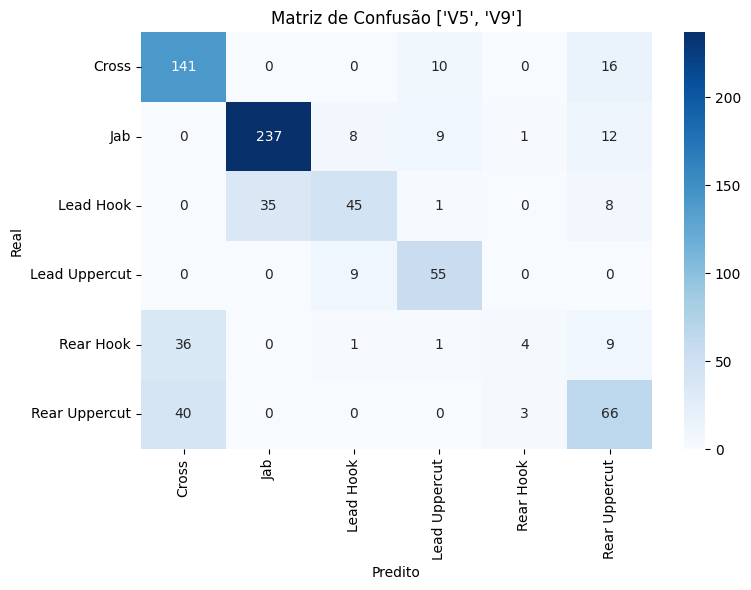

In [14]:
# Avaliar
from tensorflow.keras.models import load_model

best_model = load_model("best_model_v2.keras")
y_pred = np.argmax(best_model.predict(X_te_feat), axis=1)

print(classification_report(y_te, y_pred, target_names=classes))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.title(f'Matriz de Confusão {TEST_VIDEOS}')
plt.tight_layout()
plt.savefig("matrix.png")
plt.show()

In [16]:
best_model.save('modelo_boxe.keras')

In [20]:
import numpy as np
from tensorflow.keras.models import load_model

BOXING_CLASSES = ["Cross", "Jab", "Lead Hook", "Lead Uppercut", "Rear Hook", "Rear Uppercut"]
X_MEAN_GLOBAL = 0.1763427519365391
X_STD_GLOBAL  = 0.24370889809812205

# Carregue o modelo
model = load_model("modelo_boxe.keras")

# Carregue um dos seus videos de teste
# Opção A: Use V9 (seu video de teste original)
skeleton = np.load("dataset/skeleton_data/V9.npy")

# Normalize
skeleton_reshaped = skeleton.reshape(skeleton.shape[0], 25, 34)
X_normalized = (skeleton_reshaped - X_MEAN_GLOBAL) / X_STD_GLOBAL

# Adiciona velocidade e aceleração (igual ao treino)
vel = np.diff(X_normalized, axis=1, prepend=np.zeros_like(X_normalized[:, :1, :]))
acc = np.diff(vel, axis=1, prepend=np.zeros_like(vel[:, :1, :]))
X_test = np.concatenate([X_normalized, vel, acc], axis=-1)

print(f"Shape dos dados: {X_test.shape}")

# Teste o modelo
y_pred = np.argmax(model.predict(X_test), axis=1)

# Veja quais classes apareceram
unique, counts = np.unique(y_pred, return_counts=True)
print("\n🔍 Distribuição de classes preditas:")
for u, c in zip(unique, counts):
    print(f"  {BOXING_CLASSES[u]}: {c}")

Shape dos dados: (149, 25, 102)
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 560ms/step

🔍 Distribuição de classes preditas:
  Cross: 28
  Jab: 30
  Lead Hook: 12
  Lead Uppercut: 34
  Rear Uppercut: 45


In [22]:
# Dados offline (que funcionam)
skeleton_v9 = np.load("dataset/skeleton_data/V9.npy")
print("V9 (funciona):")
print(f"  Shape: {skeleton_v9.shape}")
print(f"  Min: {skeleton_v9.min():.4f}, Max: {skeleton_v9.max():.4f}")
print(f"  Mean: {skeleton_v9.mean():.4f}, Std: {skeleton_v9.std():.4f}")

# Dados do adam.npy (o que está quebrado)
skeleton_adam = np.load("dataset/skeleton_data/adam.npy")
print("\nadam (está quebrado):")
print(f"  Shape: {skeleton_adam.shape}")
print(f"  Min: {skeleton_adam.min():.4f}, Max: {skeleton_adam.max():.4f}")
print(f"  Mean: {skeleton_adam.mean():.4f}, Std: {skeleton_adam.std():.4f}")

# Diferença
print("\n⚠️ Diferenças:")
print(f"  Mean diff: {skeleton_adam.mean() - skeleton_v9.mean():.4f}")
print(f"  Std diff:  {skeleton_adam.std() - skeleton_v9.std():.4f}")

V9 (funciona):
  Shape: (149, 25, 17, 2)
  Min: 0.0000, Max: 0.9053
  Mean: 0.2027, Std: 0.2635

adam (está quebrado):
  Shape: (498, 17, 2)
  Min: 0.0000, Max: 0.8803
  Mean: 0.4374, Std: 0.2401

⚠️ Diferenças:
  Mean diff: 0.2347
  Std diff:  -0.0233
